In [ ]:
# Cell 1 — Environment setup and get version

!pip install -q astroquery astropy pandas numpy matplotlib scipy

import os
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

import astropy
import astropy.units as u
from astropy.coordinates import (SkyCoord, Galactocentric,
                                 CartesianDifferential, ICRS)
import astroquery
from astroquery.gaia import Gaia

VERSIONS = {
    "python":     sys.version.split()[0],
    "numpy":      np.__version__,
    "scipy":      scipy.__version__,
    "pandas":     pd.__version__,
    "matplotlib": matplotlib.__version__,
    "astropy":    astropy.__version__,
    "astroquery": astroquery.__version__,
}

print("Software environment")
print("-" * 40)
for k, v in VERSIONS.items():
    print(f"  {k:12s} {v}")

with open("software_versions.txt", "w") as fh:
    for k, v in VERSIONS.items():
        fh.write(f"{k}=={v}\n")

print("\n-> paste these into Section 3.5 of the paper")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00
Software environment
----------------------------------------
  python       3.13.15
  numpy        2.1.3
  scipy        1.16.3
  pandas       2.2.3
  matplotlib   3.10.0
  astropy      7.2.2
  astroquery   0.4.11

-> paste these into Section 3.5 of the paper


In [ ]:
# Cell 2 — Gaia DR3 sample

MAX_ROWS  = 25_000
RAW_CSV   = "gaia_raw_6d_sample.csv"
USE_CACHE = True      # set False to force a fresh archive query

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"

QUERY = f"""
SELECT TOP {MAX_ROWS}
    source_id, ra, dec, l, b,
    parallax, parallax_error,
    pmra, pmdec,
    radial_velocity, radial_velocity_error
FROM gaiadr3.gaia_source
WHERE radial_velocity IS NOT NULL
  AND radial_velocity_error IS NOT NULL
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND parallax > 0.1
  AND parallax_over_error > 10
  AND radial_velocity_error < 20
  AND ABS(b) < 20
ORDER BY random_index
"""

print("ADQL query")
print("-" * 40)
print(QUERY.strip())

with open("adql_query.sql", "w") as fh:
    fh.write(QUERY.strip() + "\n")

if USE_CACHE and os.path.exists(RAW_CSV):
    df = pd.read_csv(RAW_CSV)
    print(f"\nLoaded cached sample: {len(df):,} stars from {RAW_CSV}")
else:
    print("\nQuerying Gaia DR3 ...")
    df = Gaia.launch_job_async(QUERY).get_results().to_pandas()
    df.to_csv(RAW_CSV, index=False)
    print(f"Retrieved {len(df):,} stars -> {RAW_CSV}")

df.head()


ADQL query
----------------------------------------
SELECT TOP 25000
    source_id, ra, dec, l, b,
    parallax, parallax_error,
    pmra, pmdec,
    radial_velocity, radial_velocity_error
FROM gaiadr3.gaia_source
WHERE radial_velocity IS NOT NULL
  AND radial_velocity_error IS NOT NULL
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND parallax > 0.1
  AND parallax_over_error > 10
  AND radial_velocity_error < 20
  AND ABS(b) < 20
ORDER BY random_index

Querying Gaia DR3 ...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Retrieved 25,000 stars -> gaia_raw_6d_sample.csv


,source_id,ra,dec,l,b,parallax,parallax_error,pmra,pmdec,radial_velocity,radial_velocity_error
0,4040949706019490560,265.229363,-36.358205,353.159523,-3.052137,0.352725,0.029665,-0.570184,-5.683394,-39.548756,2.289071
1,1823532754729083392,300.805804,20.601006,59.466608,-5.523316,0.886435,0.020054,9.675645,0.425116,-32.939175,5.852169
2,6068055453656132736,198.685803,-54.101028,306.383346,8.614470,1.351779,0.018469,-3.107003,1.482269,0.551207,2.958417
3,527154051013641088,8.303528,64.995242,121.006407,2.191647,0.703967,0.018081,-3.440837,1.194513,-48.187603,3.265717
4,6084196726724370560,202.890673,-46.281027,310.127249,16.029387,2.821713,0.093853,12.731613,2.493211,66.639244,1.595879


In [ ]:
# Cell 3 — Transform to Galactocentric positions and velocities


R0       = 8.122 * u.kpc                                        # Sun-GC distance
Z_SUN    = 20.8 * u.pc                                          # solar height above plane
V_SUN    = CartesianDifferential([12.9, 245.6, 7.78] * u.km / u.s)
GC_COORD = ICRS(ra=266.4051 * u.deg, dec=-28.936175 * u.deg)

GALCEN_FRAME = Galactocentric(
    galcen_coord=GC_COORD,
    galcen_distance=R0,
    galcen_v_sun=V_SUN,
    z_sun=Z_SUN,
    roll=0 * u.deg,
)

print("Adopted Galactocentric frame")
print("-" * 40)
print(f"  R0            = {R0}")
print(f"  z_sun         = {Z_SUN}")
print(f"  galcen_v_sun  = {V_SUN.d_xyz}")
print(f"  roll          = 0 deg")

data = df.dropna(subset=["source_id", "ra", "dec", "parallax", "parallax_error",
                         "pmra", "pmdec", "radial_velocity"]).copy()

# Inverse-parallax distance. This estimator is biased: parallax errors are
# symmetric but 1/parallax is nonlinear, so inversion systematically
# overestimates distance at low S/N (Lutz & Kelker 1973; Bailer-Jones
# 2015). The parallax_over_error > 10 cut holds the fractional distance
# error below ~10% but does not remove the bias, which grows with
# distance — worst in exactly the sparse outer bins that set the outer
# slope of the rotation curve.
distance_pc = 1000.0 / data["parallax"].to_numpy()

coords = SkyCoord(
    ra=data["ra"].to_numpy() * u.deg,
    dec=data["dec"].to_numpy() * u.deg,
    distance=distance_pc * u.pc,
    pm_ra_cosdec=data["pmra"].to_numpy() * u.mas / u.yr,
    pm_dec=data["pmdec"].to_numpy() * u.mas / u.yr,
    radial_velocity=data["radial_velocity"].to_numpy() * u.km / u.s,
    frame="icrs",
)

galcen = coords.transform_to(GALCEN_FRAME)

x = galcen.x.to_value(u.kpc)
y = galcen.y.to_value(u.kpc)
z = galcen.z.to_value(u.kpc)
vx = galcen.v_x.to_value(u.km / u.s)
vy = galcen.v_y.to_value(u.km / u.s)
vz = galcen.v_z.to_value(u.km / u.s)

R    = np.hypot(x, y)
vR   = (x * vx + y * vy) / R
vphi = -(x * vy - y * vx) / R      # sign convention: prograde rotation > 0

kinematics = pd.DataFrame({
    "source_id": data["source_id"].to_numpy(),
    "R_kpc":     R,
    "z_kpc":     z,
    "vR_km_s":   vR,
    "vphi_km_s": vphi,
    "vz_km_s":   vz,
})
kinematics.to_csv("gaia_processed_kinematics.csv", index=False)

print(f"\nTransformed {len(kinematics):,} stars")
print(f"Median v_phi (full sample): {kinematics['vphi_km_s'].median():.1f} km/s")
kinematics.head()


Adopted Galactocentric frame
----------------------------------------
  R0            = 8.122 kpc
  z_sun         = 20.8 pc
  galcen_v_sun  = [ 12.9  245.6    7.78] km / s
  roll          = 0 deg

Transformed 25,000 stars
Median v_phi (full sample): 224.2 km/s


,source_id,R_kpc,z_kpc,vR_km_s,vphi_km_s,vz_km_s
0,4040949706019490560,5.322165,-0.137347,24.779024,184.025689,-23.743211
1,1823532754729083392,7.613467,-0.089240,59.839338,222.817249,-31.557895
2,6068055453656132736,7.710342,0.130494,-22.635268,238.719606,13.986810
3,527154051013641088,8.936264,0.076997,-27.347435,221.409112,15.479463
4,6084196726724370560,7.906492,0.118097,-77.667792,208.366594,26.690276


In [ ]:
# Cell 4 — Disc selection and the binned observed rotation curve

# Disc-selection cuts
R_MIN, R_MAX   = 3.0, 15.0     # kpc
Z_MAX          = 1.0           # kpc
VZ_MAX         = 100.0         # km/s
VPHI_MIN, VPHI_MAX = 50.0, 400.0   # km/s

disk = kinematics[
    (kinematics["R_kpc"] >= R_MIN) &
    (kinematics["R_kpc"] <= R_MAX) &
    (np.abs(kinematics["z_kpc"]) <= Z_MAX) &
    (np.abs(kinematics["vz_km_s"]) <= VZ_MAX) &
    (kinematics["vphi_km_s"] >= VPHI_MIN) &
    (kinematics["vphi_km_s"] <= VPHI_MAX)
].copy()

# Binning: fixed-width 0.5 kpc annuli with edges 3.0, 3.5, ..., 15.0 kpc
# (25 edges -> 24 candidate bins).
BIN_WIDTH = 0.5
MIN_STARS = 20
bin_edges = np.arange(R_MIN, R_MAX + BIN_WIDTH, BIN_WIDTH)
disk["R_bin"] = pd.cut(disk["R_kpc"], bins=bin_edges, include_lowest=True)

rotation_curve = (
    disk.groupby("R_bin", observed=True)
    .agg(
        R_kpc=("R_kpc", "median"),
        vphi_km_s=("vphi_km_s", "median"),
        velocity_scatter=("vphi_km_s", "std"),
        star_count=("source_id", "size"),
    )
    .reset_index(drop=True)
)

n_before = len(rotation_curve)
rotation_curve = rotation_curve[rotation_curve["star_count"] >= MIN_STARS].copy()

# Per-bin uncertainty on the MEDIAN.
#   The asymptotic standard error of the median for a normal sample is
#   sigma * sqrt(pi / 2N) = 1.253 * sigma / sqrt(N).
#   No bootstrap is performed. A 5 km/s floor prevents the statistical
#   sampling error from being treated as the only source of error.
ERR_FLOOR = 5.0
rotation_curve["vphi_error_km_s"] = np.maximum(
    1.253 * rotation_curve["velocity_scatter"] / np.sqrt(rotation_curve["star_count"]),
    ERR_FLOOR,
)

print(f"Disc stars retained : {len(disk):,} of {len(kinematics):,} "
      f"({100 * len(disk) / len(kinematics):.1f}%)")
print(f"Bin width           : {BIN_WIDTH} kpc")
print(f"Bin edges           : {bin_edges[0]:.1f} to {bin_edges[-1]:.1f} kpc "
      f"({len(bin_edges) - 1} candidate bins)")
print(f"Bins with N >= {MIN_STARS}  : {len(rotation_curve)} of {n_before} populated")
print(f"Radial range        : {rotation_curve['R_kpc'].min():.2f} - "
      f"{rotation_curve['R_kpc'].max():.2f} kpc")
print(f"Star counts         : {rotation_curve['star_count'].min()} - "
      f"{rotation_curve['star_count'].max()} per bin")
print("\nNOTE: the sparse outer bins carry the largest formal uncertainties")
print("      (error ~ N^-1/2) yet they set the outer slope the halo is fitted to.")

rotation_curve.to_csv("gaia_binned_vphi_curve.csv", index=False)
rotation_curve


Disc stars retained : 24,421 of 25,000 (97.7%)
Bin width           : 0.5 kpc
Bin edges           : 3.0 to 15.0 kpc (24 candidate bins)
Bins with N >= 20  : 19 of 24 populated
Radial range        : 3.80 - 12.73 kpc
Star counts         : 26 - 4803 per bin

NOTE: the sparse outer bins carry the largest formal uncertainties
      (error ~ N^-1/2) yet they set the outer slope the halo is fitted to.


,R_kpc,vphi_km_s,velocity_scatter,star_count,vphi_error_km_s
1,3.801668,192.783611,65.280165,29,15.189145
2,4.314200,195.784029,52.302825,90,6.908042
3,4.791978,205.607429,46.859106,239,5.000000
4,5.291725,211.585987,40.420042,537,5.000000
5,5.775807,213.532353,37.648406,886,5.000000
6,6.268092,219.944649,33.757477,1280,5.000000
7,6.775443,224.048995,30.308842,2046,5.000000
8,7.274859,225.376929,28.401060,3347,5.000000
9,7.762514,228.088755,26.594314,4803,5.000000
10,8.236816,226.476069,24.976096,4509,5.000000


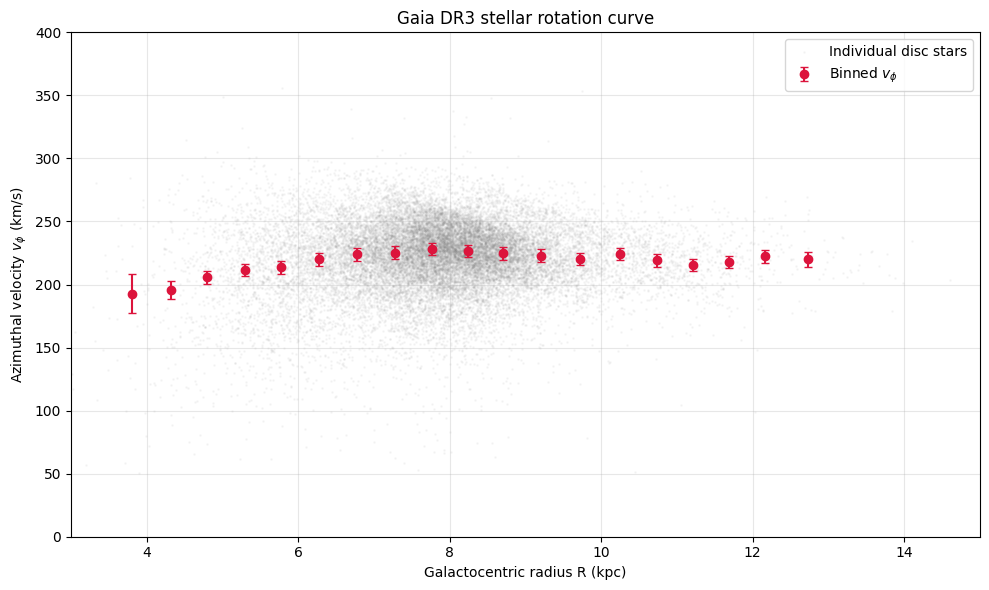

In [ ]:
# Cell 5 — Figure 1: observed v_phi rotation curve

plt.figure(figsize=(10, 6))
plt.scatter(disk["R_kpc"], disk["vphi_km_s"],
            s=1, alpha=0.05, color="gray", label="Individual disc stars")
plt.errorbar(rotation_curve["R_kpc"], rotation_curve["vphi_km_s"],
             yerr=rotation_curve["vphi_error_km_s"], fmt="o",
             color="crimson", capsize=3, label=r"Binned $v_\phi$")
plt.xlabel("Galactocentric radius R (kpc)")
plt.ylabel(r"Azimuthal velocity $v_\phi$ (km/s)")
plt.title("Gaia DR3 stellar rotation curve")
plt.xlim(3, 15)
plt.ylim(0, 400)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("fig1_observed_rotation_curve.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 6 — Exploratory Jeans asymmetric-drift correction (with diagnostics)

jeans_curve = (
    disk.groupby("R_bin", observed=True)
    .agg(
        R_kpc=("R_kpc", "median"),
        vphi_sq=("vphi_km_s", lambda s: np.mean(s ** 2)),
        vR_sq=("vR_km_s", lambda s: np.mean(s ** 2)),
        star_count=("source_id", "size"),
    )
    .reset_index(drop=True)
)
jeans_curve = jeans_curve[jeans_curve["star_count"] >= MIN_STARS].copy()

Rj      = jeans_curve["R_kpc"].to_numpy()
Nj      = jeans_curve["star_count"].to_numpy()
vR_sq   = jeans_curve["vR_sq"].to_numpy()
vphi_sq = jeans_curve["vphi_sq"].to_numpy()

# Surface-density proxy for fixed-width annuli: nu ~ N / R
nu_proxy = Nj / Rj

dlnnu_dlnR  = np.gradient(np.log(nu_proxy), np.log(Rj))
dlnvR2_dlnR = np.gradient(np.log(vR_sq), np.log(Rj))

bracket = 1.0 + dlnnu_dlnR + dlnvR2_dlnR
vc_sq   = vphi_sq - vR_sq * bracket

jeans_curve["dlnnu_dlnR"] = dlnnu_dlnR
jeans_curve["bracket"]    = bracket
jeans_curve["vc_km_s"]    = np.sqrt(np.maximum(vc_sq, 0.0))

# Numerical gradients and the unmodelled selection function, not Poisson
# noise, dominate the error budget here: use a conservative 10% floor.
jeans_curve["vc_error_km_s"] = np.maximum(0.10 * jeans_curve["vc_km_s"], 8.0)

# ── Diagnostics ────────────────────────────────────────────────────────
peak_i = int(np.argmax(Nj))
print("TRACER-DENSITY DIAGNOSTIC")
print("-" * 68)
print(f"Star counts peak at R = {Rj[peak_i]:.2f} kpc (N = {Nj[peak_i]})")
print(f"dln(nu)/dln(R): {dlnnu_dlnR.min():+.1f} to {dlnnu_dlnR.max():+.1f}")
print("The sign reversal is set by where a magnitude-limited Gaia sample")
print("peaks (near the Sun), NOT by Galactic structure. The correction")
print("therefore inherits the selection function.\n")

n_unphys = int(np.sum(bracket < 0))
print("UNPHYSICAL-CORRECTION DIAGNOSTIC")
print("-" * 68)
print(f"Bins with bracket < 0 (correction ADDS speed): {n_unphys} of {len(Rj)}")
if n_unphys:
    print(f"  first at R = {Rj[bracket < 0].min():.2f} kpc")
    print("  WARNING: asymmetric drift must satisfy v_c >= <v_phi>.")
    print("           These bins violate that and are not trustworthy.\n")

dropped = jeans_curve[jeans_curve["vc_km_s"] <= 0]
if len(dropped):
    print("DROPPED BINS (v_c^2 <= 0)")
    print("-" * 68)
    for _, r in dropped.iterrows():
        print(f"  R = {r['R_kpc']:.2f} kpc  (N = {int(r['star_count'])})  "
              f"bracket = {r['bracket']:+.2f}")
    print()

jeans_curve = jeans_curve[np.isfinite(jeans_curve["vc_km_s"]) &
                          (jeans_curve["vc_km_s"] > 0)].copy()

# Arrays used by every downstream cell
R_fit = jeans_curve["R_kpc"].to_numpy()
v_fit = jeans_curve["vc_km_s"].to_numpy()
e_fit = jeans_curve["vc_error_km_s"].to_numpy()
N_fit = jeans_curve["star_count"].to_numpy()

print("FITTED SAMPLE")
print("-" * 68)
print(f"Observed v_phi curve : {len(rotation_curve)} bins, "
      f"{rotation_curve['R_kpc'].min():.2f} - {rotation_curve['R_kpc'].max():.2f} kpc")
print(f"Jeans-corrected fit  : {len(R_fit)} bins, "
      f"{R_fit.min():.2f} - {R_fit.max():.2f} kpc")
print("These ranges differ. All fit statistics below refer to the second.")

jeans_curve.to_csv("gaia_jeans_corrected_curve.csv", index=False)
jeans_curve[["R_kpc", "star_count", "dlnnu_dlnR", "bracket",
             "vc_km_s", "vc_error_km_s"]]


TRACER-DENSITY DIAGNOSTIC
--------------------------------------------------------------------
Star counts peak at R = 7.76 kpc (N = 4803)
dln(nu)/dln(R): -19.5 to +8.1
The sign reversal is set by where a magnitude-limited Gaia sample
peaks (near the Sun), NOT by Galactic structure. The correction
therefore inherits the selection function.

UNPHYSICAL-CORRECTION DIAGNOSTIC
--------------------------------------------------------------------
Bins with bracket < 0 (correction ADDS speed): 10 of 19
  first at R = 8.24 kpc
           These bins violate that and are not trustworthy.

DROPPED BINS (v_c^2 <= 0)
--------------------------------------------------------------------
  R = 3.80 kpc  (N = 29)  bracket = +8.40

FITTED SAMPLE
--------------------------------------------------------------------
Observed v_phi curve : 19 bins, 3.80 - 12.73 kpc
Jeans-corrected fit  : 18 bins, 4.31 - 12.73 kpc
These ranges differ. All fit statistics below refer to the second.


,R_kpc,star_count,dlnnu_dlnR,bracket,vc_km_s,vc_error_km_s
2,4.314200,90,8.142606,7.593555,84.372748,8.437275
3,4.791978,239,7.713373,5.968533,151.888366,15.188837
4,5.291725,537,5.864186,4.735700,185.333418,18.533342
5,5.775807,886,4.088360,3.751440,194.210281,19.421028
6,6.268092,1280,4.280936,3.690389,202.932952,20.293295
7,6.775443,2046,5.493408,4.852972,204.506699,20.450670
8,7.274859,3347,5.212506,4.849655,208.807549,20.880755
9,7.762514,4803,1.101986,1.092643,223.172907,22.317291
10,8.236816,4509,-5.089308,-5.117497,239.928366,23.992837
11,8.709831,3061,-10.873070,-10.904398,252.787270,25.278727


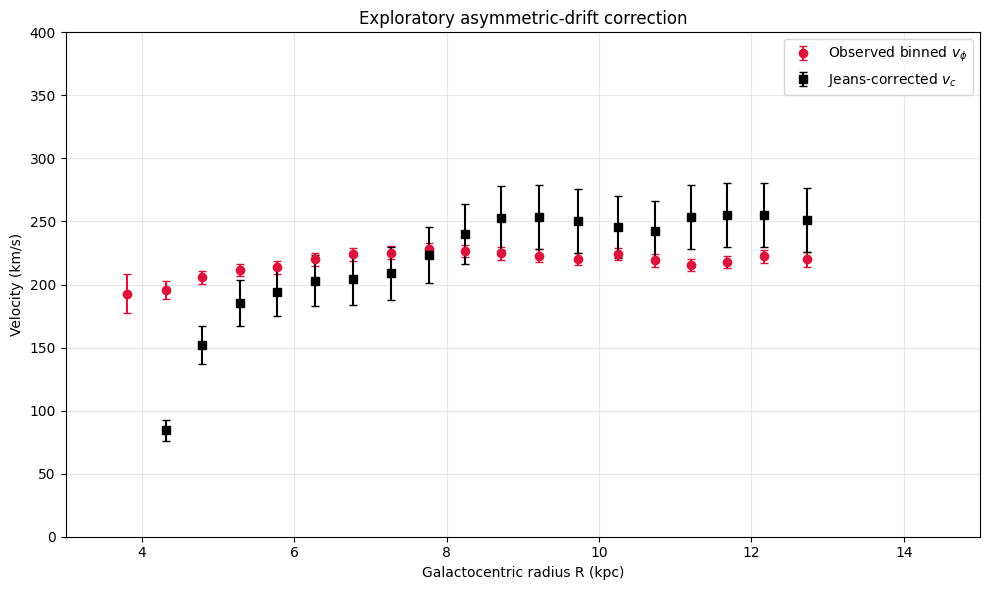

Bins where v_c < v_phi (unphysical negative drift): 8 of 18
  worst offset: -111.4 km/s


In [ ]:

# Cell 7 — Figure 2: observed v_phi versus Jeans-corrected v_c

plt.figure(figsize=(10, 6))
plt.errorbar(rotation_curve["R_kpc"], rotation_curve["vphi_km_s"],
             yerr=rotation_curve["vphi_error_km_s"], fmt="o",
             color="crimson", capsize=3, label=r"Observed binned $v_\phi$")
plt.errorbar(R_fit, v_fit, yerr=e_fit, fmt="s",
             color="black", capsize=3, label=r"Jeans-corrected $v_c$")
plt.xlabel("Galactocentric radius R (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Exploratory asymmetric-drift correction")
plt.xlim(3, 15)
plt.ylim(0, 400)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("fig2_jeans_correction.png", dpi=200, bbox_inches="tight")
plt.show()

# Where does the correction become unphysical?
merged = pd.merge(rotation_curve[["R_kpc", "vphi_km_s"]].round(4),
                  jeans_curve[["R_kpc", "vc_km_s"]].round(4),
                  on="R_kpc", how="inner")
merged["vc_minus_vphi"] = merged["vc_km_s"] - merged["vphi_km_s"]
bad = merged[merged["vc_minus_vphi"] < 0.0]
print(f"Bins where v_c < v_phi (unphysical negative drift): {len(bad)} "
      f"of {len(merged)}")
if len(bad):
    print(f"  worst offset: {bad['vc_minus_vphi'].min():+.1f} km/s")


In [ ]:
# Cell 8 — Fixed baryonic model (Hernquist bulge + two Miyamoto-Nagai discs)

G = 4.30091e-6          # kpc (km/s)^2 / Msun

M_BULGE, A_BULGE                = 0.9e10, 0.7        # Msun, kpc
M_STELLAR_DISK, A_STELLAR, B_STELLAR = 5.0e10, 3.5, 0.30
M_GAS_DISK, A_GAS, B_GAS        = 1.0e10, 4.0, 0.10

M_BARYON_TOTAL = M_BULGE + M_STELLAR_DISK + M_GAS_DISK


def bulge_velocity(R):
    """Hernquist bulge:  v^2 = G M R / (R + a)^2   [Eq. 11]."""
    R = np.asarray(R, dtype=float)
    return np.sqrt(G * M_BULGE * R / (R + A_BULGE) ** 2)


def miyamoto_nagai_velocity(R, mass, a, b):
    """Miyamoto-Nagai mid-plane (z = 0) circular speed   [Eq. 13]."""
    R = np.asarray(R, dtype=float)
    v_sq = G * mass * R ** 2 / (R ** 2 + (a + b) ** 2) ** 1.5
    return np.sqrt(np.maximum(v_sq, 0.0))


def baryonic_velocity(R):
    """Bulge + stellar disc + gas disc, added in quadrature."""
    return np.sqrt(bulge_velocity(R) ** 2
                   + miyamoto_nagai_velocity(R, M_STELLAR_DISK, A_STELLAR, B_STELLAR) ** 2
                   + miyamoto_nagai_velocity(R, M_GAS_DISK, A_GAS, B_GAS) ** 2)


print("Fixed baryonic model")
print("-" * 52)
print(f"  Hernquist bulge  M = {M_BULGE:.2e} Msun,  a = {A_BULGE} kpc")
print(f"  MN stellar disc  M = {M_STELLAR_DISK:.2e} Msun,  "
      f"a = {A_STELLAR} kpc, b = {B_STELLAR} kpc")
print(f"  MN gas disc      M = {M_GAS_DISK:.2e} Msun,  "
      f"a = {A_GAS} kpc, b = {B_GAS} kpc")
print(f"  TOTAL BARYONS    M = {M_BARYON_TOTAL:.2e} Msun")


Fixed baryonic model
----------------------------------------------------
  Hernquist bulge  M = 9.00e+09 Msun,  a = 0.7 kpc
  MN stellar disc  M = 5.00e+10 Msun,  a = 3.5 kpc, b = 0.3 kpc
  MN gas disc      M = 1.00e+10 Msun,  a = 4.0 kpc, b = 0.1 kpc
  TOTAL BARYONS    M = 6.90e+10 Msun


In [ ]:

# Cell 9 — NFW halo and the total mass model

H0_KM_S_MPC = 67.4
H0          = H0_KM_S_MPC / 1000.0                 # km/s/kpc
RHO_CRIT    = 3.0 * H0 ** 2 / (8.0 * np.pi * G)    # Msun/kpc^3

print(f"H0        = {H0_KM_S_MPC} km/s/Mpc")
print(f"rho_crit  = {RHO_CRIT:.4f} Msun/kpc^3   (200 x rho_crit convention)")


def f_nfw(x):
    """NFW mass function f(x) = ln(1+x) - x/(1+x)."""
    return np.log1p(x) - x / (1.0 + x)


def nfw_derived_parameters(log10_M200, concentration):
    """Convert (log10 M200, c) -> (r200, r_s, rho_s)."""
    M200 = 10.0 ** log10_M200
    r200 = (3.0 * M200 / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)
    r_s = r200 / concentration
    rho_s = (200.0 / 3.0) * RHO_CRIT * concentration ** 3 / f_nfw(concentration)
    return r200, r_s, rho_s


def nfw_velocity_and_mass(R, log10_M200, concentration):
    """NFW circular speed and enclosed dark mass at radius R."""
    R = np.asarray(R, dtype=float)
    M200 = 10.0 ** log10_M200
    _, r_s, _ = nfw_derived_parameters(log10_M200, concentration)
    M_enclosed = M200 * f_nfw(R / r_s) / f_nfw(concentration)
    return np.sqrt(G * M_enclosed / R), M_enclosed


def total_velocity_model(R, log10_M200, concentration):
    """Baryons + NFW halo, added in quadrature   [Eq. 6]."""
    v_halo, _ = nfw_velocity_and_mass(R, log10_M200, concentration)
    return np.sqrt(baryonic_velocity(R) ** 2 + v_halo ** 2)


H0        = 67.4 km/s/Mpc
rho_crit  = 126.0784 Msun/kpc^3   (200 x rho_crit convention)


In [ ]:
# Cell 10 — Baryon-only baseline  (NEW)

v_baryon_only = baryonic_velocity(R_fit)
chi2_baryon   = float(np.sum(((v_fit - v_baryon_only) / e_fit) ** 2))
dof_baryon    = len(v_fit)

print("BARYON-ONLY BASELINE (no halo, 0 free parameters)")
print("-" * 52)
print(f"  chi^2         = {chi2_baryon:.2f}")
print(f"  d.o.f.        = {dof_baryon}")
print(f"  reduced chi^2 = {chi2_baryon / dof_baryon:.2f}")


BARYON-ONLY BASELINE (no halo, 0 free parameters)
----------------------------------------------------
  chi^2         = 288.13
  d.o.f.        = 18
  reduced chi^2 = 16.01


In [ ]:
# Cell 11 — Fit the four-component model (only the 2 NFW parameters free)

P0     = [12.0, 12.0]                      # log10 M200, c
BOUNDS = ([10.5, 1.0], [13.5, 40.0])       # Eq. 21

best_params, covariance = curve_fit(
    total_velocity_model, R_fit, v_fit,
    sigma=e_fit, absolute_sigma=True,
    p0=P0, bounds=BOUNDS, maxfev=30000,
)

log10_M200, concentration = best_params
perr = np.sqrt(np.diag(covariance))

v_model_fit = total_velocity_model(R_fit, *best_params)
residuals   = v_fit - v_model_fit
chi2_nfw    = float(np.sum((residuals / e_fit) ** 2))
dof_nfw     = len(v_fit) - len(best_params)

print("FIT RESULT")
print("-" * 52)
print(f"  bounds: log10(M200) in [{BOUNDS[0][0]}, {BOUNDS[1][0]}], "
      f"c in [{BOUNDS[0][1]}, {BOUNDS[1][1]}]")
print(f"  log10(M200/Msun) = {log10_M200:.3f} +/- {perr[0]:.3f}")
print(f"  concentration c  = {concentration:.2f} +/- {perr[1]:.2f}")
print(f"  M200             = {10 ** log10_M200:.3e} Msun")
print(f"  chi^2 / d.o.f.   = {chi2_nfw:.2f} / {dof_nfw} "
      f"= {chi2_nfw / dof_nfw:.2f}")

# ── Boundary check ─────────────────────────────────────────────────────
TOL = 1e-3
at_bound = []
for name, val, lo, hi in [("log10(M200)", log10_M200, BOUNDS[0][0], BOUNDS[1][0]),
                          ("c",           concentration, BOUNDS[0][1], BOUNDS[1][1])]:
    if abs(val - lo) < TOL:
        at_bound.append(f"{name} pinned to LOWER bound {lo}")
    elif abs(val - hi) < TOL:
        at_bound.append(f"{name} pinned to UPPER bound {hi}")

if at_bound:
    print("\n  *** BOUNDARY SOLUTION ***")
    for msg in at_bound:
        print(f"    {msg}")
    print("    A parameter pinned to its prior edge carries no information")
    print("    beyond 'the optimiser wanted to go further'. Do NOT quote")
    print("    this as a measured virial mass or concentration.")

for name, val, err in [("log10(M200)", log10_M200, perr[0]),
                       ("c", concentration, perr[1])]:
    if err > abs(val):
        print(f"  *** {name}: formal uncertainty ({err:.2f}) exceeds the "
              f"value ({val:.2f}) ***")

# ── Model comparison ───────────────────────────────────────────────────
delta_chi2 = chi2_baryon - chi2_nfw
print("\nMODEL COMPARISON")
print("-" * 52)
print(f"  {'model':<26} {'chi2':>9} {'dof':>5} {'red.chi2':>10}")
print(f"  {'baryons only':<26} {chi2_baryon:9.2f} {dof_baryon:5d} "
      f"{chi2_baryon / dof_baryon:10.2f}")
print(f"  {'baryons + NFW halo':<26} {chi2_nfw:9.2f} {dof_nfw:5d} "
      f"{chi2_nfw / dof_nfw:10.2f}")
print(f"  Delta chi^2 = {delta_chi2:.2f} for 2 extra parameters")
print("\n  The halo improves the fit significantly, but neither model is an")
print("  acceptable description of the corrected curve.")


FIT RESULT
----------------------------------------------------
  bounds: log10(M200) in [10.5, 13.5], c in [1.0, 40.0]
  log10(M200/Msun) = 13.500 +/- 7.755
  concentration c  = 2.37 +/- 14.80
  M200             = 3.162e+13 Msun
  chi^2 / d.o.f.   = 226.11 / 16 = 14.13

  *** BOUNDARY SOLUTION ***
    log10(M200) pinned to UPPER bound 13.5
    A parameter pinned to its prior edge carries no information
    beyond 'the optimiser wanted to go further'. Do NOT quote
    this as a measured virial mass or concentration.
  *** c: formal uncertainty (14.80) exceeds the value (2.37) ***

MODEL COMPARISON
----------------------------------------------------
  model                           chi2   dof   red.chi2
  baryons only                  288.13    18      16.01
  baryons + NFW halo            226.11    16      14.13
  Delta chi^2 = 62.02 for 2 extra parameters

  The halo improves the fit significantly, but neither model is an
  acceptable description of the corrected curve.


In [ ]:
# Cell 12 — Derived halo shape parameters and the degeneracy

r200_fit, r_s_fit, rho_s_fit = nfw_derived_parameters(log10_M200, concentration)
x_max = R_fit.max() / r_s_fit

print("DERIVED NFW SHAPE PARAMETERS")
print("-" * 60)
print(f"  r200   = {r200_fit:.1f} kpc")
print(f"  r_s    = {r_s_fit:.1f} kpc")
print(f"  rho_s  = {rho_s_fit:.4e} Msun/kpc^3")
print(f"  rho_s * r_s = {rho_s_fit * r_s_fit:.4e} Msun/kpc^2")

print("\nHOW DEEP INTO THE HALO DO THE DATA REACH?")
print("-" * 60)
print(f"  R_max / r_s = {x_max:.4f}")
print(f"  f(x_max)    = {f_nfw(x_max):.4e}")
print(f"  x_max^2 / 2 = {x_max ** 2 / 2:.4e}   (small-x limit)")
print(f"  ratio       = {f_nfw(x_max) / (x_max ** 2 / 2):.3f}")
print("\n  For x << 1, f(x) -> x^2/2, so")
print("      M_NFW(<r) -> 2 pi rho_s r_s r^2")
print("      v_NFW^2(R) -> 2 pi G (rho_s r_s) R          [Eq. 22]")
print("  Only the PRODUCT rho_s * r_s is constrained. The halo shape")
print("  is not measured by data over this radial baseline.")

corr = covariance[0, 1] / np.sqrt(covariance[0, 0] * covariance[1, 1])
print("\nPARAMETER COVARIANCE")
print("-" * 60)
print(f"  correlation r(log10 M200, c) = {corr:.4f}")
if abs(corr) > 0.95:
    print("  *** Near-total degeneracy: the two NFW parameters are not")
    print("      separately identifiable. Report an ENCLOSED MASS, not a halo.")


DERIVED NFW SHAPE PARAMETERS
------------------------------------------------------------
  r200   = 669.0 kpc
  r_s    = 282.1 kpc
  rho_s  = 2.1888e+05 Msun/kpc^3
  rho_s * r_s = 6.1756e+07 Msun/kpc^2

HOW DEEP INTO THE HALO DO THE DATA REACH?
------------------------------------------------------------
  R_max / r_s = 0.0451
  f(x_max)    = 9.5944e-04
  x_max^2 / 2 = 1.0177e-03   (small-x limit)
  ratio       = 0.943

  For x << 1, f(x) -> x^2/2, so
      M_NFW(<r) -> 2 pi rho_s r_s r^2
      v_NFW^2(R) -> 2 pi G (rho_s r_s) R          [Eq. 22]
  Only the PRODUCT rho_s * r_s is constrained. The halo shape
  is not measured by data over this radial baseline.

PARAMETER COVARIANCE
------------------------------------------------------------
  correlation r(log10 M200, c) = -0.9997
  *** Near-total degeneracy: the two NFW parameters are not
      separately identifiable. Report an ENCLOSED MASS, not a halo.


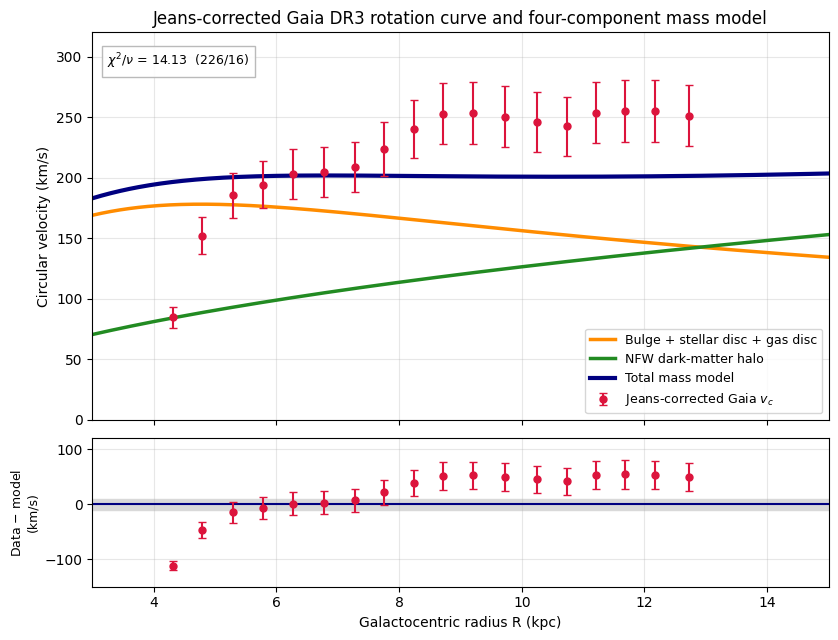

RESIDUAL STRUCTURE
--------------------------------------------------------------------
  sign pattern  : ----++++++++++++++
  sign changes  : 1 across 18 ordered points
  *** Strongly systematic, not random. A well-specified model with
      correct errors scatters residuals about zero. This pattern
      indicates MODEL MISSPECIFICATION (Jeans correction and/or
      the fixed baryonic model), not a missing halo component.

CHI^2 BUDGET (largest contributors)
--------------------------------------------------------------------
    R (kpc)      N     resid    sigma    chi2_i    share
       4.31     90    -112.0   -13.27    176.18    77.9%
       4.79    239     -46.8    -3.08      9.51     4.2%
      11.68    125     +54.2    +2.12      4.51     2.0%
      12.16     56     +53.8    +2.11      4.46     2.0%
      11.21    205     +52.8    +2.08      4.33     1.9%

  Worst bin alone contributes 77.9% of chi^2 = 226.11
  Excluding it: chi^2 = 49.93 / 15 = 3.33
  The goodness-of-fit stat

In [ ]:
# Cell 13 — Figure 3: component decomposition WITH a residual panel

from matplotlib.gridspec import GridSpec

R_model = np.linspace(3.0, 15.0, 400)
v_baryon_model = baryonic_velocity(R_model)
v_halo_model, M_halo_model = nfw_velocity_and_mass(R_model, *best_params)
v_total_model = total_velocity_model(R_model, *best_params)

fig = plt.figure(figsize=(9.5, 7.2))
gs = GridSpec(2, 1, height_ratios=[3, 1.15], hspace=0.07)

ax = fig.add_subplot(gs[0])
ax.errorbar(R_fit, v_fit, yerr=e_fit, fmt="o", color="crimson",
            capsize=3, ms=5, zorder=5, label=r"Jeans-corrected Gaia $v_c$")
ax.plot(R_model, v_baryon_model, color="darkorange", lw=2.5,
        label="Bulge + stellar disc + gas disc")
ax.plot(R_model, v_halo_model, color="forestgreen", lw=2.5,
        label="NFW dark-matter halo")
ax.plot(R_model, v_total_model, color="navy", lw=3, label="Total mass model")
ax.set_ylabel("Circular velocity (km/s)")
ax.set_xlim(3, 15)
ax.set_ylim(0, 320)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.tick_params(labelbottom=False)
ax.set_title("Jeans-corrected Gaia DR3 rotation curve and four-component mass model")
ax.text(0.02, 0.95,
        r"$\chi^2/\nu$ = %.2f  (%.0f/%d)" % (chi2_nfw / dof_nfw, chi2_nfw, dof_nfw),
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))

axr = fig.add_subplot(gs[1], sharex=ax)
axr.axhline(0, color="navy", lw=1.5)
axr.axhspan(-10, 10, color="0.85", zorder=0)
axr.errorbar(R_fit, residuals, yerr=e_fit, fmt="o", color="crimson",
             capsize=3, ms=5)
axr.set_xlabel("Galactocentric radius R (kpc)")
axr.set_ylabel("Data $-$ model\n(km/s)", fontsize=9)
axr.set_xlim(3, 15)
axr.set_ylim(-150, 120)
axr.grid(alpha=0.3)

plt.savefig("fig3_fit_with_residuals.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Residual structure and chi^2 budget ────────────────────────────────
signs = "".join("+" if r > 0 else "-" for r in residuals)
n_sign_changes = sum(1 for i in range(1, len(signs)) if signs[i] != signs[i - 1])

print("RESIDUAL STRUCTURE")
print("-" * 68)
print(f"  sign pattern  : {signs}")
print(f"  sign changes  : {n_sign_changes} across {len(residuals)} ordered points")
if n_sign_changes <= 2:
    print("  *** Strongly systematic, not random. A well-specified model with")
    print("      correct errors scatters residuals about zero. This pattern")
    print("      indicates MODEL MISSPECIFICATION (Jeans correction and/or")
    print("      the fixed baryonic model), not a missing halo component.")

contrib = (residuals / e_fit) ** 2
order = np.argsort(contrib)[::-1]
print("\nCHI^2 BUDGET (largest contributors)")
print("-" * 68)
print(f"  {'R (kpc)':>9} {'N':>6} {'resid':>9} {'sigma':>8} {'chi2_i':>9} {'share':>8}")
for i in order[:5]:
    print(f"  {R_fit[i]:9.2f} {N_fit[i]:6d} {residuals[i]:+9.1f} "
          f"{residuals[i] / e_fit[i]:+8.2f} {contrib[i]:9.2f} "
          f"{100 * contrib[i] / contrib.sum():7.1f}%")

worst = order[0]
print(f"\n  Worst bin alone contributes {100 * contrib[worst] / contrib.sum():.1f}% "
      f"of chi^2 = {chi2_nfw:.2f}")
keep = np.ones(len(R_fit), dtype=bool)
keep[worst] = False
chi2_ex = float(contrib[keep].sum())
dof_ex = int(keep.sum()) - 2
print(f"  Excluding it: chi^2 = {chi2_ex:.2f} / {dof_ex} = {chi2_ex / dof_ex:.2f}")
print("  The goodness-of-fit statistic is therefore not a fair summary of")
print("  the model across the range.")


CHI^2 GRID
------------------------------------------------------------
  grid minimum   chi^2 = 226.11 at log10 M200 = 13.500, c = 2.34
  curve_fit      chi^2 = 226.11   (consistency check)

  68% region (Delta chi^2 <= 2.3):
    log10 M200      : 12.96 -> 13.50
    c               : 1.86 -> 3.57
    M_DM(<12.73 kpc): 4.711e+10 -> 7.123e+10 Msun
    -> enclosed mass spread +/-20.6%

  95% region (Delta chi^2 <= 6.17):
    log10 M200      : 12.48 -> 13.50
    c               : 1.61 -> 5.03
    M_DM(<12.73 kpc): 3.951e+10 -> 8.048e+10 Msun
    -> enclosed mass spread +/-34.9%


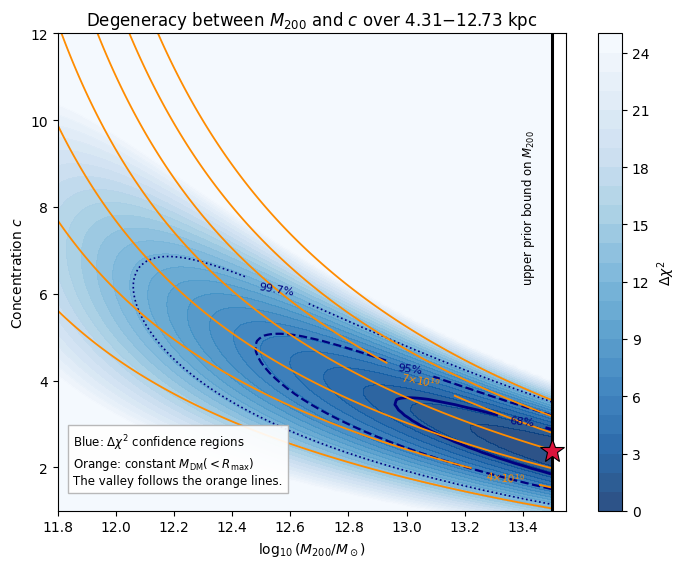

In [ ]:
# Cell 14 — Figure 4: the M200-c degeneracy

N_GRID = 320
grid_m = np.linspace(BOUNDS[0][0], BOUNDS[1][0], N_GRID)
grid_c = np.linspace(BOUNDS[0][1], BOUNDS[1][1], N_GRID)
GM, GC = np.meshgrid(grid_m, grid_c, indexing="ij")

# Vectorised over the full grid
M200_g = 10.0 ** GM
r200_g = (3.0 * M200_g / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)
r_s_g = r200_g / GC
x_g = R_fit[None, None, :] / r_s_g[:, :, None]
M_enc_g = M200_g[:, :, None] * f_nfw(x_g) / f_nfw(GC)[:, :, None]
v_halo_g = np.sqrt(G * M_enc_g / R_fit[None, None, :])
v_tot_g = np.sqrt(baryonic_velocity(R_fit)[None, None, :] ** 2 + v_halo_g ** 2)
CHI = np.sum(((v_fit[None, None, :] - v_tot_g) / e_fit[None, None, :]) ** 2, axis=2)
MENC = M_enc_g[:, :, int(np.argmax(R_fit))]

chi_min = float(CHI.min())
idx = np.unravel_index(int(CHI.argmin()), CHI.shape)
DCHI = CHI - chi_min

print("CHI^2 GRID")
print("-" * 60)
print(f"  grid minimum   chi^2 = {chi_min:.2f} at "
      f"log10 M200 = {GM[idx]:.3f}, c = {GC[idx]:.2f}")
print(f"  curve_fit      chi^2 = {chi2_nfw:.2f}   (consistency check)")

for dchi, label in [(2.30, "68%"), (6.17, "95%")]:
    m = DCHI <= dchi
    print(f"\n  {label} region (Delta chi^2 <= {dchi}):")
    print(f"    log10 M200      : {GM[m].min():.2f} -> {GM[m].max():.2f}")
    print(f"    c               : {GC[m].min():.2f} -> {GC[m].max():.2f}")
    print(f"    M_DM(<{R_fit.max():.2f} kpc): {MENC[m].min():.3e} -> "
          f"{MENC[m].max():.3e} Msun")
    print(f"    -> enclosed mass spread +/-"
          f"{100 * (MENC[m].max() - MENC[m].min()) / 2 / MENC[idx]:.1f}%")

m68 = DCHI <= 2.30
M_DM_LO, M_DM_HI = float(MENC[m68].min()), float(MENC[m68].max())

fig, ax = plt.subplots(figsize=(8.2, 6.2))
cf = ax.contourf(GM, GC, np.clip(DCHI, 0, 25), levels=np.linspace(0, 25, 26),
                 cmap="Blues_r", alpha=0.85)
cs = ax.contour(GM, GC, DCHI, levels=[2.30, 6.17, 11.8], colors="navy",
                linewidths=[2.0, 1.6, 1.2], linestyles=["-", "--", ":"])
ax.clabel(cs, fmt={2.30: "68%", 6.17: "95%", 11.8: "99.7%"}, fontsize=8)

mass_levels = np.array([3, 4, 5, 6, 7, 8, 9]) * 1e10
cm = ax.contour(GM, GC, MENC, levels=mass_levels, colors="darkorange",
                linewidths=1.3)
ax.clabel(cm, fmt=lambda v: r"%.0f$\times10^{10}$" % (v / 1e10), fontsize=7.5)

ax.plot(log10_M200, concentration, "*", color="crimson", ms=18,
        mec="k", mew=0.8, zorder=6)
ax.axvline(BOUNDS[1][0], color="k", lw=2.2)
ax.text(BOUNDS[1][0] - 0.05, 8.0, "upper prior bound on $M_{200}$",
        rotation=90, ha="right", va="center", fontsize=8.5)

ax.set_xlabel(r"$\log_{10}(M_{200}/M_\odot)$")
ax.set_ylabel(r"Concentration $c$")
ax.set_xlim(11.8, BOUNDS[1][0] + 0.05)
ax.set_ylim(1.0, 12)
ax.set_title(r"Degeneracy between $M_{200}$ and $c$ over "
             f"{R_fit.min():.2f}$-${R_fit.max():.2f} kpc")
ax.text(0.03, 0.05,
        "Blue: $\\Delta\\chi^2$ confidence regions\n"
        "Orange: constant $M_{\\rm DM}(<R_{\\max})$\n"
        "The valley follows the orange lines.",
        transform=ax.transAxes, fontsize=8.5, va="bottom",
        bbox=dict(fc="white", ec="0.7", alpha=0.92))
fig.colorbar(cf, ax=ax, label=r"$\Delta\chi^2$")
plt.savefig("fig4_degeneracy.png", dpi=200, bbox_inches="tight")
plt.show()


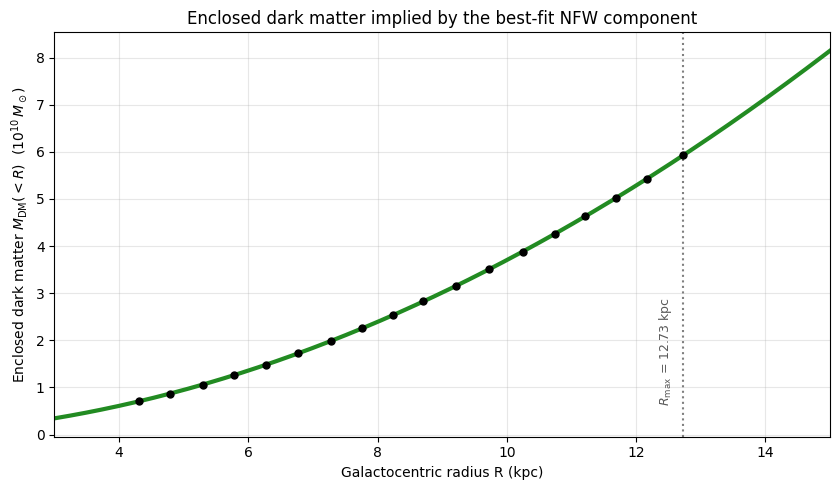

ENCLOSED DARK MATTER
------------------------------------------------------------
  Outermost fitted radius : 12.73 kpc
  M_DM(<12.73 kpc)      : 5.927e+10 Msun
  68% range               : 4.711e+10 - 7.123e+10 Msun
  fractional half-width   : +/-20.3%

  For context, the FIXED baryonic model contains 6.90e+10 Msun in total.
  This number is conditional on the NFW form, on the fixed baryonic
  parameters, and on the Jeans correction. Quote all three caveats.


In [ ]:
# Cell 15 — Figure 5: enclosed dark matter, with a 68% range

v_halo_fit, M_dark_enclosed = nfw_velocity_and_mass(R_fit, *best_params)
i_outer = int(np.argmax(R_fit))
R_outer = R_fit[i_outer]
M_DM_OUT = float(M_dark_enclosed[i_outer])

plt.figure(figsize=(8.5, 5))
plt.plot(R_model, M_halo_model / 1e10, color="forestgreen", lw=3)
plt.scatter(R_fit, M_dark_enclosed / 1e10, color="black", s=25, zorder=5)
plt.axvline(R_outer, color="0.5", ls=":", lw=1.5)
plt.text(R_outer - 0.15, 0.6, f"$R_{{\\max}}$ = {R_outer:.2f} kpc",
         rotation=90, ha="right", va="bottom", fontsize=9, color="0.35")
plt.xlabel("Galactocentric radius R (kpc)")
plt.ylabel(r"Enclosed dark matter $M_{\rm DM}(<R)$  ($10^{10}\,M_\odot$)")
plt.title("Enclosed dark matter implied by the best-fit NFW component")
plt.xlim(3, 15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_enclosed_dark_matter.png", dpi=200, bbox_inches="tight")
plt.show()

print("ENCLOSED DARK MATTER")
print("-" * 60)
print(f"  Outermost fitted radius : {R_outer:.2f} kpc")
print(f"  M_DM(<{R_outer:.2f} kpc)      : {M_DM_OUT:.3e} Msun")
print(f"  68% range               : {M_DM_LO:.3e} - {M_DM_HI:.3e} Msun")
print(f"  fractional half-width   : "
      f"+/-{100 * (M_DM_HI - M_DM_LO) / 2 / M_DM_OUT:.1f}%")
print(f"\n  For context, the FIXED baryonic model contains "
      f"{M_BARYON_TOTAL:.2e} Msun in total.")
print("  This number is conditional on the NFW form, on the fixed baryonic")
print("  parameters, and on the Jeans correction. Quote all three caveats.")


In [ ]:
# Cell 16 — Save results and print every number quoted in the paper

M_dyn_spherical_equiv = R_fit * v_fit ** 2 / G

results = pd.DataFrame({
    "R_kpc": R_fit,
    "star_count": N_fit,
    "jeans_corrected_vc_km_s": v_fit,
    "vc_error_km_s": e_fit,
    "baryonic_velocity_km_s": baryonic_velocity(R_fit),
    "dark_matter_velocity_km_s": v_halo_fit,
    "total_model_velocity_km_s": v_model_fit,
    "residual_km_s": residuals,
    "residual_sigma": residuals / e_fit,
    "dark_matter_enclosed_Msun": M_dark_enclosed,
    "spherical_equivalent_dynamical_mass_Msun": M_dyn_spherical_equiv,
})
results.to_csv("jeans_corrected_dark_matter_profile.csv", index=False)

summary = {
    "n_raw": int(len(df)),
    "n_disc": int(len(disk)),
    "n_bins_vphi": int(len(rotation_curve)),
    "vphi_R_min_kpc": float(rotation_curve["R_kpc"].min()),
    "vphi_R_max_kpc": float(rotation_curve["R_kpc"].max()),
    "n_bins_fitted": int(len(R_fit)),
    "fit_R_min_kpc": float(R_fit.min()),
    "fit_R_max_kpc": float(R_fit.max()),
    "log10_M200": float(log10_M200),
    "log10_M200_err": float(perr[0]),
    "concentration": float(concentration),
    "concentration_err": float(perr[1]),
    "M200_Msun": float(10 ** log10_M200),
    "rho_s_Msun_kpc3": float(rho_s_fit),
    "r_s_kpc": float(r_s_fit),
    "r200_kpc": float(r200_fit),
    "Rmax_over_rs": float(x_max),
    "correlation_M200_c": float(corr),
    "chi2_baryon_only": float(chi2_baryon),
    "dof_baryon_only": int(dof_baryon),
    "chi2_nfw": float(chi2_nfw),
    "dof_nfw": int(dof_nfw),
    "reduced_chi2_nfw": float(chi2_nfw / dof_nfw),
    "delta_chi2": float(delta_chi2),
    "M_DM_enclosed_Msun": M_DM_OUT,
    "M_DM_enclosed_lo_68": M_DM_LO,
    "M_DM_enclosed_hi_68": M_DM_HI,
    "M_baryon_total_Msun": float(M_BARYON_TOTAL),
}

import json
with open("results_summary.json", "w") as fh:
    json.dump({"versions": VERSIONS, "results": summary}, fh, indent=2)

print("=" * 68)
print("SUMMARY — every number quoted in the paper")
print("=" * 68)
print(f"Sample         : {summary['n_raw']:,} retrieved, "
      f"{summary['n_disc']:,} after disc cuts")
print(f"Observed curve : {summary['n_bins_vphi']} bins, "
      f"{summary['vphi_R_min_kpc']:.2f}-{summary['vphi_R_max_kpc']:.2f} kpc")
print(f"Fitted curve   : {summary['n_bins_fitted']} bins, "
      f"{summary['fit_R_min_kpc']:.2f}-{summary['fit_R_max_kpc']:.2f} kpc")
print("-" * 68)
print(f"log10(M200)    = {summary['log10_M200']:.3f} +/- "
      f"{summary['log10_M200_err']:.3f}   [BOUNDARY SOLUTION]")
print(f"c              = {summary['concentration']:.2f} +/- "
      f"{summary['concentration_err']:.2f}")
print(f"rho_s          = {summary['rho_s_Msun_kpc3']:.3e} Msun/kpc^3")
print(f"r_s            = {summary['r_s_kpc']:.1f} kpc")
print(f"r200           = {summary['r200_kpc']:.1f} kpc")
print(f"R_max / r_s    = {summary['Rmax_over_rs']:.4f}")
print(f"corr(M200, c)  = {summary['correlation_M200_c']:.4f}")
print("-" * 68)
print(f"baryons only   : chi2 = {summary['chi2_baryon_only']:.2f} / "
      f"{summary['dof_baryon_only']} = "
      f"{summary['chi2_baryon_only'] / summary['dof_baryon_only']:.2f}")
print(f"baryons + NFW  : chi2 = {summary['chi2_nfw']:.2f} / "
      f"{summary['dof_nfw']} = {summary['reduced_chi2_nfw']:.2f}")
print(f"Delta chi2     = {summary['delta_chi2']:.2f} for 2 extra parameters")
print("-" * 68)
print(f"M_DM(<{summary['fit_R_max_kpc']:.2f} kpc) = "
      f"{summary['M_DM_enclosed_Msun']:.3e} Msun")
print(f"   68% range   = {summary['M_DM_enclosed_lo_68']:.3e} - "
      f"{summary['M_DM_enclosed_hi_68']:.3e} Msun")
print(f"M_baryon total = {summary['M_baryon_total_Msun']:.3e} Msun")
print("=" * 68)
print("\nNO virial mass and NO concentration are claimed.")
print("Written: results_summary.json, jeans_corrected_dark_matter_profile.csv")

results


SUMMARY — every number quoted in the paper
Sample         : 25,000 retrieved, 24,421 after disc cuts
Observed curve : 19 bins, 3.80-12.73 kpc
Fitted curve   : 18 bins, 4.31-12.73 kpc
--------------------------------------------------------------------
log10(M200)    = 13.500 +/- 7.755   [BOUNDARY SOLUTION]
c              = 2.37 +/- 14.80
rho_s          = 2.189e+05 Msun/kpc^3
r_s            = 282.1 kpc
r200           = 669.0 kpc
R_max / r_s    = 0.0451
corr(M200, c)  = -0.9997
--------------------------------------------------------------------
baryons only   : chi2 = 288.13 / 18 = 16.01
baryons + NFW  : chi2 = 226.11 / 16 = 14.13
Delta chi2     = 62.02 for 2 extra parameters
--------------------------------------------------------------------
M_DM(<12.73 kpc) = 5.927e+10 Msun
   68% range   = 4.711e+10 - 7.123e+10 Msun
M_baryon total = 6.900e+10 Msun

NO virial mass and NO concentration are claimed.
Written: results_summary.json, jeans_corrected_dark_matter_profile.csv


,R_kpc,star_count,jeans_corrected_vc_km_s,vc_error_km_s,baryonic_velocity_km_s,dark_matter_velocity_km_s,total_model_velocity_km_s,residual_km_s,residual_sigma,dark_matter_enclosed_Msun,spherical_equivalent_dynamical_mass_Msun
0,4.314200,90,84.372748,8.437275,177.489242,83.997012,196.361730,-111.988983,-13.273123,7.077300e+09,7.140758e+09
1,4.791978,239,151.888366,15.188837,177.973353,88.427626,198.730872,-46.842506,-3.084009,8.712251e+09,2.570416e+10
2,5.291725,537,185.333418,18.533342,177.478646,92.816383,200.283675,-14.950257,-0.806668,1.059952e+10,4.226145e+10
3,5.775807,886,194.210281,19.421028,176.285406,96.859979,201.142736,-6.932455,-0.356956,1.259914e+10,5.065202e+10
4,6.268092,1280,202.932952,20.293295,174.561220,100.788332,201.568617,1.364335,0.067231,1.480456e+10,6.001782e+10
5,6.775443,2046,204.506699,20.450670,172.414736,104.665026,201.696824,2.809875,0.137398,1.725761e+10,6.588589e+10
6,7.274859,3347,208.807549,20.880755,170.062148,108.328806,201.633986,7.173563,0.343549,1.984962e+10,7.374908e+10
7,7.762514,4803,223.172907,22.317291,167.624546,111.774922,201.473625,21.699281,0.972308,2.254918e+10,8.989281e+10
8,8.236816,4509,239.928366,23.992837,165.180916,115.013409,201.277965,38.650401,1.610914,2.533355e+10,1.102458e+11
9,8.709831,3061,252.787270,25.278727,162.714819,118.141170,201.080701,51.706569,2.045458,2.826519e+10,1.294076e+11
